In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pickle
import torch
from torch_geometric.data import Data

In [2]:
def sinusoidal_positional_encoding(N, d_model):
    pe = torch.zeros(N, d_model)
    position = torch.arange(0, N, dtype=torch.float).unsqueeze(1)
    div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-torch.log(torch.tensor(10000.0)) / d_model))
    pe[:, 0::2] = torch.sin(position * div_term)
    pe[:, 1::2] = torch.cos(position * div_term)
    return pe  # shape [N, d_model]

In [89]:
import numpy as np
import torch
from torch_geometric.data import Data

def build_graph_contact(sequence, score_map, distance_map=None,contact_cutoff=8.0, sep_min=5):
    
    N = len(sequence)

    src, dst = [], []
    edge_scores = []
    edge_labels = []
    edge_mask = []
    edge_pair_mask = []   # use only one direction for supervision/eval 

    score_map = np.log(np.array(score_map) + 1)

    for i in range(N):
        for j in range(N):
            if i == j:
                continue

            src.append(i)
            dst.append(j)

            edge_scores.append(score_map[i, j])

            # devo tenere solo un contatto o tutte e due le coppie?
            pair_ok = (i < j)
            edge_pair_mask.append(pair_ok)

            # ignore short-range pairs ?
            long_range_ok = abs(i - j) >= sep_min

            if distance_map is not None:
                d = distance_map[i, j]
                known = not torch.isinf(torch.tensor(d))
                label = float(known and (d <= contact_cutoff))
            else:
                known = True
                label = 0.0

            edge_labels.append(label)
            #let's consider only the contact that are not inf and that are relevant
            edge_mask.append(known and long_range_ok)

    x = sinusoidal_positional_encoding(N, d_model=16)

    edge_index = torch.tensor([src, dst], dtype=torch.long)
    edge_attr = torch.tensor(edge_scores, dtype=torch.float).unsqueeze(-1)
    y = torch.tensor(edge_labels, dtype=torch.float).unsqueeze(-1)

    mask = torch.tensor(edge_mask, dtype=torch.bool)
    pair_mask = torch.tensor(edge_pair_mask, dtype=torch.bool)

    return Data(
        x=x,
        edge_index=edge_index,
        edge_attr=edge_attr,
        y=y,                 # binary contact labels
        edge_mask=mask,      # valid + long-range
        pair_mask=pair_mask, # only one direction per pair
        L=N
    )

In [90]:
folder_path = "Data"

all_data = []
for file in os.listdir(folder_path):
    if file.endswith(".pkl"):
        full_path = os.path.join(folder_path, file)
        
        with open(full_path, "rb") as f:
            loaded = pickle.load(f)

        sequence=loaded['sequence']
        distance_map=loaded['distance_map']
        contact_map_DCA=loaded['dca']
        data = build_graph_contact(sequence, contact_map_DCA, distance_map)
        all_data.append(data)

from torch_geometric.loader import DataLoader
from sklearn.model_selection import train_test_split

train_data, test_data = train_test_split(all_data, test_size=0.2, random_state=0)


train_loader = DataLoader(train_data, batch_size=10, shuffle=True)
#train_loader = DataLoader([all_data[3]], batch_size=1)
test_loader = DataLoader(test_data, batch_size=1, shuffle=False)

In [43]:
import torch.nn as nn
from torch_geometric.nn import MessagePassing


# MessagePassing Module    
class EdgeMessagePassingLayer(MessagePassing):

    def __init__ (self, node_in_ch, edge_in_ch, node_out_ch, edge_out_ch, aggr='mean'):
        super(EdgeMessagePassingLayer, self).__init__(aggr=aggr, flow='source_to_target')  # <---- aggregation

        #print('Relu activation')

        # Edge MLP: [e_ij, x_i, x_j] -> e'_ij
        self.lin_phi_e = nn.Sequential(
            nn.Linear(edge_in_ch + 2 * node_in_ch, edge_out_ch),
            nn.LeakyReLU(negative_slope=0.2),
            #nn.ReLU(),
            nn.Linear(edge_out_ch, edge_out_ch)
        )

        # Node MLP: [x_i(old), agg([x_i, x_j, e'_ij] sugli edge incidenti a i)] -> x_i(new)
        self.lin_phi_x = nn.Sequential(
            nn.Linear(node_in_ch + (2 * node_in_ch + edge_out_ch),  node_out_ch),
            nn.LeakyReLU(negative_slope=0.2),
            #nn.ReLU(),
            nn.Linear(node_out_ch, node_out_ch)
        )
    
    def forward(self, x, edge_index, edge_attr):
        assert edge_attr is not None, 'Questa GNN runna solo con edge_attr!'
        
        # 1. Update edges
        edge_attr = self.edge_updater(edge_index, x=x, edge_attr=edge_attr)
        # 2. Update nodes
        x_out = self.propagate(edge_index, x=x, edge_attr=edge_attr)

        return x_out, edge_attr

    # -- EDGES --  <--- self.edge_updater
    def edge_update(self, x_i, x_j, edge_attr):
        edge_attr_out = self.lin_phi_e( torch.cat([edge_attr, x_i, x_j], dim=-1) )
        return edge_attr_out
        
    # -- NODES --   <--- self.propagate
    def message(self, x_i, x_j, edge_attr):
        message = torch.cat([x_i, x_j, edge_attr], dim=-1)
        return message

    # ... aggregate con mean o add nell'init ...

    def update(self, aggr_out, x):
        aggr = torch.cat([x, aggr_out], dim=-1)
        x_out = self.lin_phi_x(aggr)
        return x_out

In [44]:
from torch_geometric.nn import LayerNorm
import torch.nn.functional as F

class EdgeGNN(nn.Module):
    def __init__(self, node_in_ch = 8, edge_in_ch = 8, node_out_ch = 1, multipl_mid_layers = 2, edge_out_ch = 2, GNN_layers=4, node_norms =True, edge_norms=True, gating=True):
        super(EdgeGNN, self).__init__() 

        self.convs = nn.ModuleList()
        self.node_norms = nn.ModuleList() if node_norms else None
        self.edge_norms = nn.ModuleList() if edge_norms else None
        self.gating = nn.ModuleList() if gating else None

        # First layer
        if self.node_norms is not None:
            self.node_norms.append(LayerNorm(node_in_ch))
        if self.edge_norms is not None:
            self.edge_norms.append(LayerNorm(edge_in_ch))
        self.convs.append(EdgeMessagePassingLayer(
            node_in_ch = node_in_ch,
            edge_in_ch = edge_in_ch,
            node_out_ch = node_in_ch * multipl_mid_layers,
            edge_out_ch = edge_in_ch * multipl_mid_layers
        ))
        if self.gating is not None:
            self.gating.append(nn.Sequential(
            nn.Linear(edge_in_ch * multipl_mid_layers, edge_in_ch * multipl_mid_layers),
            nn.Sigmoid()
            ))

        # Layer Intermedi
        for _ in range(GNN_layers - 2):
            if self.node_norms is not None:
                self.node_norms.append(LayerNorm(node_in_ch * multipl_mid_layers))
            if self.edge_norms is not None:
                self.edge_norms.append(LayerNorm(edge_in_ch * multipl_mid_layers))

            self.convs.append(EdgeMessagePassingLayer(
                node_in_ch=node_in_ch * multipl_mid_layers,
                edge_in_ch=edge_in_ch * multipl_mid_layers,
                node_out_ch=node_in_ch * multipl_mid_layers,
                edge_out_ch=edge_in_ch * multipl_mid_layers
            ))
            
            if self.gating is not None:
                self.gating.append(nn.Sequential(
                nn.Linear(edge_in_ch * multipl_mid_layers, edge_in_ch * multipl_mid_layers),
                nn.Sigmoid()
                ))

        # Final Intermediate layer
        self.convs.append(EdgeMessagePassingLayer(
            node_in_ch=node_in_ch * multipl_mid_layers,
            edge_in_ch=edge_in_ch * multipl_mid_layers,
            node_out_ch=node_out_ch,
            edge_out_ch=edge_out_ch
        ))

    def forward(self, graph):
        x, edge_index, edge_attr, batch = graph.x, graph.edge_index, graph.edge_attr, graph.batch

        edge_batch = batch[edge_index[0]]  # batch degli edge = batch del nodo sorgente

        for i, (node_norm, edge_norm, conv) in enumerate(zip(self.node_norms, self.edge_norms, self.convs[:-1])):
            x_in = x
            e_in = edge_attr
            x = node_norm(x, batch) if node_norm is not None else x
            edge_attr = edge_norm(edge_attr, edge_batch) if edge_norm is not None else edge_attr

            x, edge_attr = conv(x, edge_index, edge_attr)

            if x_in.shape == x.shape:
                x = x + x_in
            if e_in.shape == edge_attr.shape:
                gate = self.gating[i](edge_attr) if self.gating is not None else 1.0
                edge_attr = edge_attr * gate  # edge gating
                edge_attr = edge_attr + e_in

            x = F.leaky_relu(x, negative_slope=0.2)
            edge_attr = F.leaky_relu(edge_attr, negative_slope=0.2)

            #x = self.dropout(x)
            #edge_attr = self.dropout(edge_attr)

        # Final projection to output space
        x, edge_attr = self.convs[-1](x, edge_index, edge_attr)

        return x, edge_attr

In [91]:
def compute_pos_weight(loader, device):
    total_pos = 0
    total_neg = 0

    for batch in loader:
        batch = batch.to(device)

        y = batch.y.squeeze(-1)
        mask = batch.edge_mask #& batch.pair_mask  

        y = y[mask]

        total_pos += (y == 1).sum().item()
        total_neg += (y == 0).sum().item()

    pos_weight = total_neg / max(total_pos, 1)
    return torch.tensor(pos_weight, dtype=torch.float, device=device)

In [92]:
def average_loss(model, loader, loss_fn, device):
    model.eval()
    total_loss = 0.0
    total_edges = 0
    total_batches= 0

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)

            _, pred_logits = model(batch)
            pred_logits = pred_logits.squeeze(-1)
            true_contacts = batch.y.squeeze(-1)

            mask = batch.edge_mask #& batch.pair_mask

            loss = loss_fn(pred_logits[mask], true_contacts[mask])

            n_edges = mask.sum().item()
            total_loss += loss.item() * n_edges
            total_edges += n_edges
            total_batches += 1

    return total_loss / max(total_edges, 1)


In [93]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = EdgeGNN(node_in_ch=16, edge_in_ch=1, edge_out_ch=1, GNN_layers=5).to(device)

pos_weight = compute_pos_weight(train_loader, device)
print("pos_weight:", pos_weight.item())
loss_fn = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight,reduction='mean')

optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

train_losses = []
val_losses = []

for epoch in range(200):

    model.train()

    for batch in train_loader:

        batch = batch.to(device)
        optimizer.zero_grad()

        _, pred_logits = model(batch)

        pred_logits = pred_logits.squeeze(-1)
        true_contacts = batch.y.squeeze(-1)

        mask = batch.edge_mask #& batch.pair_mask

        loss = loss_fn(pred_logits[mask], true_contacts[mask])

        loss.backward()
        optimizer.step()

    train_loss = average_loss(model, train_loader, loss_fn, device)
    val_loss = average_loss(model, test_loader, loss_fn, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch}: Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}")

pos_weight: 14.878605842590332
Epoch 0: Train Loss=1.3014, Val Loss=1.2186
Epoch 1: Train Loss=1.2726, Val Loss=1.1718
Epoch 2: Train Loss=1.2787, Val Loss=1.1858
Epoch 3: Train Loss=1.2452, Val Loss=1.1431
Epoch 4: Train Loss=1.2081, Val Loss=1.1002
Epoch 5: Train Loss=1.1507, Val Loss=1.0443
Epoch 6: Train Loss=1.1137, Val Loss=0.9832
Epoch 7: Train Loss=1.1015, Val Loss=0.9799
Epoch 8: Train Loss=1.0961, Val Loss=0.9727
Epoch 9: Train Loss=1.0926, Val Loss=0.9726
Epoch 10: Train Loss=1.0889, Val Loss=0.9700
Epoch 11: Train Loss=1.0790, Val Loss=0.9687
Epoch 12: Train Loss=1.0686, Val Loss=0.9512
Epoch 13: Train Loss=1.0568, Val Loss=0.9403
Epoch 14: Train Loss=1.0547, Val Loss=0.9379
Epoch 15: Train Loss=1.0417, Val Loss=0.9357
Epoch 16: Train Loss=1.0408, Val Loss=0.9334
Epoch 17: Train Loss=1.0329, Val Loss=0.9186
Epoch 18: Train Loss=1.0369, Val Loss=0.9249
Epoch 19: Train Loss=1.0334, Val Loss=0.9222
Epoch 20: Train Loss=1.0357, Val Loss=0.9167
Epoch 21: Train Loss=1.0393, Val L

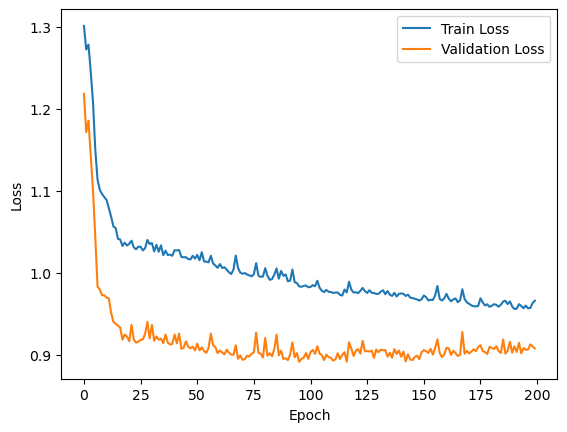

In [94]:
import matplotlib.pyplot as plt

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [101]:
#loader = DataLoader([train_loader.dataset[10]], batch_size=1)
# loader = DataLoader([test_data[2]], batch_size=1)
# batch = next(iter(loader)).to(device)
k=6

prec=[]
prec_dca=[]
for batch in test_loader:
    batch = batch.to(device)

    #accuracy for a single batch
    with torch.no_grad():
        _, pred_logits = model(batch)
        scores = torch.sigmoid(pred_logits.squeeze(-1))
        scores_dca = batch.edge_attr.squeeze(-1)  # DCA scores

    mask = batch.edge_mask & batch.pair_mask
    scores = scores[mask]
    scores_dca = scores_dca[mask]
    true_contacts = batch.y.squeeze(-1)[mask]

    L = batch.L
    topk = int(k * L)

    topk_idx = torch.topk(scores, k=min(topk, scores.numel())).indices
    topk_idx_dca = torch.topk(scores_dca, k=min(topk, scores_dca.numel())).indices

    topk_true = true_contacts[topk_idx]
    topk_true_dca = true_contacts[topk_idx_dca]

    num_correct = topk_true.sum()
    precision = (num_correct / len(topk_true)).item()
    prec.append(precision)

    num_correct_dca = topk_true_dca.sum()
    precision_dca = (num_correct_dca / len(topk_true_dca)).item()
    prec_dca.append(precision_dca)


print(f"Precision of the GNN: {np.mean(prec)}")
print(f"Precision of the DCA: {np.mean(prec_dca)}")

Precision of the GNN: 0.3665765518391574
Precision of the DCA: 0.3477293970408263


Validation ROC AUC GNN: 0.8186910342903814
Validation ROC AUC DCA: 0.7234370637596403


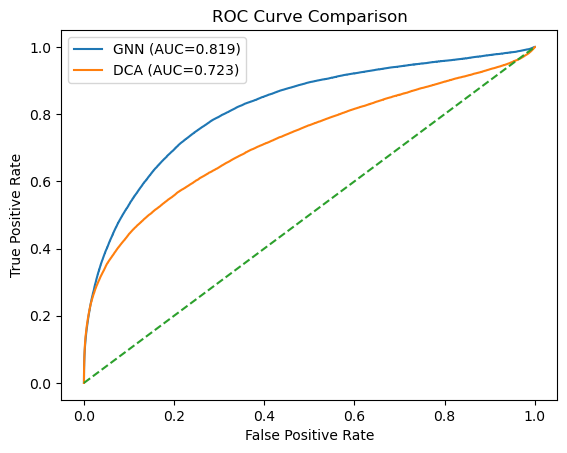

In [104]:
from sklearn.metrics import roc_curve, auc

model.eval()

all_labels = []

all_scores = []
all_scores_dca = []

with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)

        _, pred_logits = model(batch)
        scores = torch.sigmoid(pred_logits.squeeze(-1))
        dca_scores = batch.edge_attr.squeeze(-1)

        mask = batch.edge_mask & batch.pair_mask

        true_contacts = batch.y.squeeze(-1)[mask]
        y_score = scores[mask]

        all_labels.append(true_contacts.cpu())
        all_scores.append(y_score.cpu())
        all_scores_dca.append(dca_scores[mask].cpu())

# concatenate all batches
all_labels = torch.cat(all_labels).numpy()
all_scores = torch.cat(all_scores).numpy()
all_scores_dca = torch.cat(all_scores_dca).numpy()

# compute ROC
fpr, tpr, _ = roc_curve(all_labels, all_scores)
roc_auc = auc(fpr, tpr)

fpr_dca, tpr_dca, _ = roc_curve(all_labels, all_scores_dca)
roc_auc_dca = auc(fpr_dca, tpr_dca)

print("Validation ROC AUC GNN:", roc_auc)
print("Validation ROC AUC DCA:", roc_auc_dca)


plt.figure()

plt.plot(fpr, tpr, label=f"GNN (AUC={roc_auc:.3f})")
plt.plot(fpr_dca, tpr_dca, label=f"DCA (AUC={roc_auc_dca:.3f})")

plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()

PR AUC GNN: 0.32845435201622764
PR AUC GNN: 0.28970009758381987


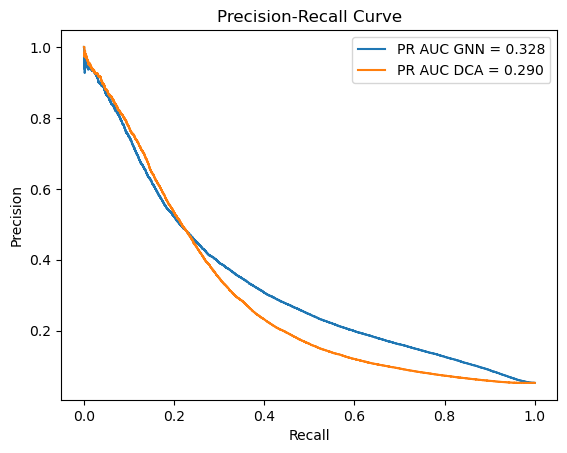

In [103]:
from sklearn.metrics import precision_recall_curve, auc

precision, recall, _ = precision_recall_curve(all_labels, all_scores)
pr_auc = auc(recall, precision)

precision_dca, recall_dca, _ = precision_recall_curve(all_labels, all_scores_dca)
pr_auc_dca = auc(recall_dca, precision_dca)


print("PR AUC GNN:", pr_auc)
print("PR AUC GNN:", pr_auc_dca)


plt.figure()
plt.plot(recall, precision, label=f"PR AUC GNN = {pr_auc:.3f}")
plt.plot(recall_dca, precision_dca, label=f"PR AUC DCA = {pr_auc_dca:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()

plt.show()

In [56]:
#We want the precision for each graph to see the distribution
def precision_at_kL_per_graph(batch, pred_logits, k):
    scores = torch.sigmoid(pred_logits.squeeze(-1))
    y_true = batch.y.squeeze(-1)

    mask = batch.edge_mask & batch.pair_mask

    scores = scores[mask]
    y_true = y_true[mask]

    edge_batch = batch.batch[batch.edge_index[0]][mask]

    precisions = []


    for g in edge_batch.unique():
        g_mask = edge_batch == g

        g_scores = scores[g_mask]
        g_true = y_true[g_mask]

        L = batch.L[g].item() if isinstance(batch.L, torch.Tensor) else batch.L

        kL = int(k * L)
        kL = min(kL, g_scores.numel())

        if kL == 0:
            continue

        topk_idx = torch.topk(g_scores, kL).indices
        topk_true = g_true[topk_idx]

        precision = topk_true.float().mean().item()
        precisions.append(precision)
    
    return precisions

#the same but for dca
def precision_at_kL_dca_per_graph(batch, k):
    scores = batch.edge_attr.squeeze(-1)  # DCA scores
    y_true = batch.y.squeeze(-1)

    mask = batch.edge_mask & batch.pair_mask

    scores = scores[mask]
    y_true = y_true[mask]

    edge_batch = batch.batch[batch.edge_index[0]][mask]

    precisions = []

    for g in edge_batch.unique():
        g_mask = edge_batch == g

        g_scores = scores[g_mask]
        g_true = y_true[g_mask]

        L = batch.L[g].item() if isinstance(batch.L, torch.Tensor) else batch.L

        kL = int(k * L)
        kL = min(kL, g_scores.numel())

        if kL == 0:
            continue

        topk_idx = torch.topk(g_scores, kL).indices
        topk_true = g_true[topk_idx]

        precision = topk_true.float().mean().item()
        precisions.append(precision)

    return precisions

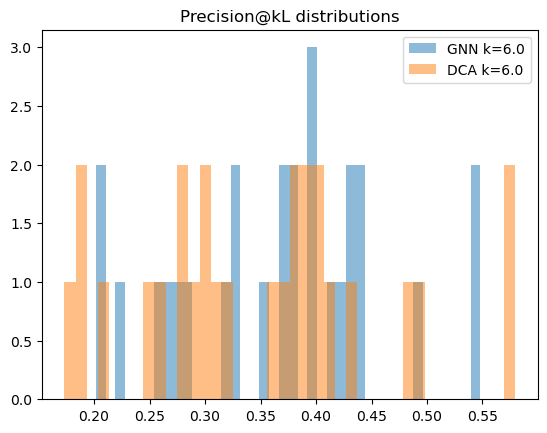

In [105]:
k_values = [6.0]

results = {k: [] for k in k_values}
results_dca = {k: [] for k in k_values}

with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        _, pred_logits = model(batch)

        for k in k_values:
            vals= precision_at_kL_per_graph(batch, pred_logits, k)
            vals_dca= precision_at_kL_dca_per_graph(batch, k)
            results[k].extend(vals)
            results_dca[k].extend(vals_dca)

for k in k_values:
    plt.hist(results[k], bins=40, alpha=0.5, label=f"GNN k={k}")
    plt.hist(results_dca[k], bins=40, alpha=0.5, label=f"DCA k={k}")

plt.legend()
plt.title("Precision@kL distributions")
plt.show()

In [106]:
k=6.0 
precision=[]
for batch in test_loader:
        batch = batch.to(device)
        _, pred_logits = model(batch)
        vals= precision_at_kL_per_graph(batch, pred_logits, k)
        precision.append(vals)
print(precision)
print(min(precision))
print(precision.index(min(precision)))

[[0.2017543911933899], [0.4405320882797241], [0.26208651065826416], [0.4283154010772705], [0.3227272629737854], [0.5474106669425964], [0.37719300389289856], [0.42901235818862915], [0.2685753405094147], [0.3962264358997345], [0.3954635262489319], [0.41856062412261963], [0.3704128563404083], [0.3565022349357605], [0.39393940567970276], [0.41460904479026794], [0.22067901492118835], [0.273333340883255], [0.3290598392486572], [0.37222224473953247], [0.3245614171028137], [0.5480480790138245], [0.20663468539714813], [0.43943798542022705], [0.3795214295387268], [0.4937106668949127], [0.28703704476356506]]
[0.2017543911933899]
0


In [107]:
def graph_to_matrix(data, values):
    num_nodes = data.x.shape[0]
    mat = torch.zeros((num_nodes, num_nodes))

    edge_index = data.edge_index
    mat[edge_index[0], edge_index[1]] = values.squeeze()

    return mat

Data(x=[76, 16], edge_index=[2, 5700], edge_attr=[5700, 1], y=[5700, 1], edge_mask=[5700], pair_mask=[5700], L=76)


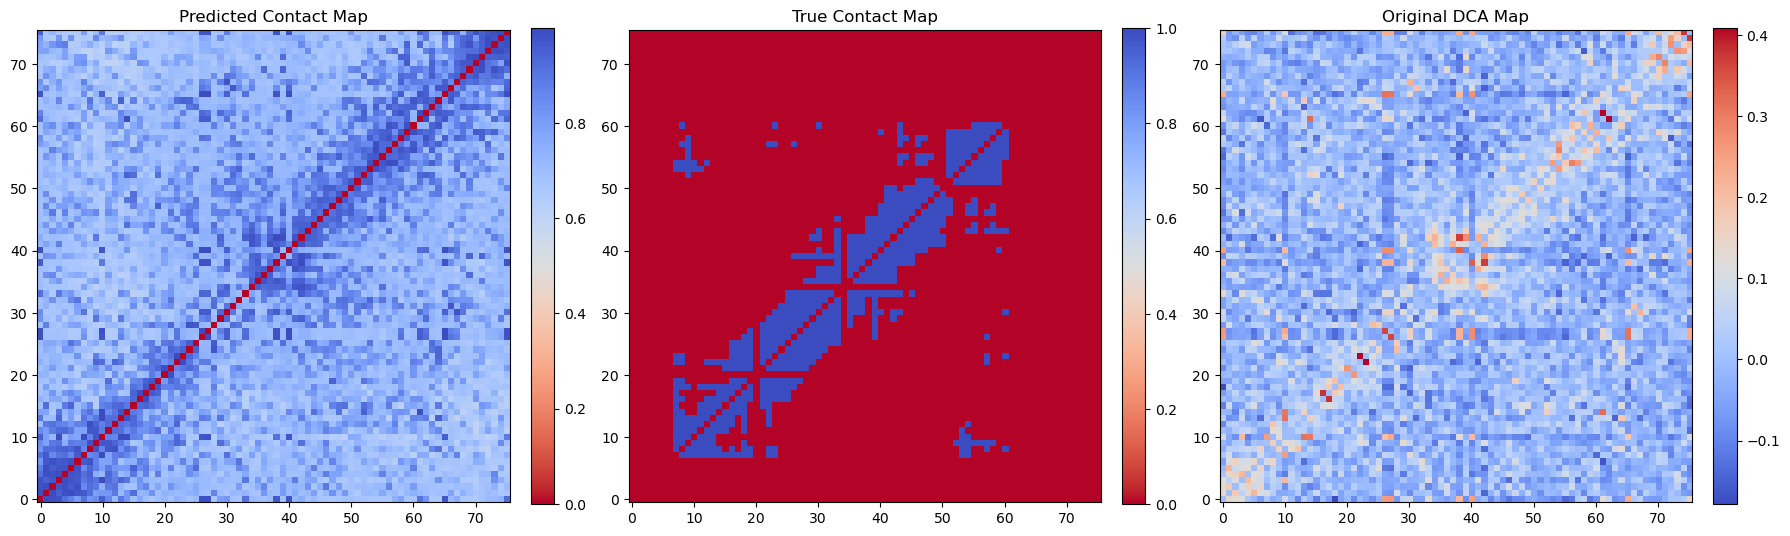

In [112]:
pos=0


i=0
with torch.no_grad():
    for batch in test_loader:
        if i==pos:
            batch = batch.to(device)
            _, pred_logits = model(batch)
        i+=1

batch=test_data[pos]
print(batch)

mask = batch.edge_mask & batch.pair_mask

scores = torch.sigmoid(pred_logits.squeeze(-1))
pred_contact_map = graph_to_matrix(batch, scores.cpu())
true_contact_map = graph_to_matrix(batch, batch.y.cpu())
original_dca_map = graph_to_matrix(batch, batch.edge_attr.cpu())


fig, axes = plt.subplots(1, 3, figsize=(18, 6))  # 1 row, 3 columns

# --- Predicted Distance Map ---
im0 = axes[0].imshow(pred_contact_map, cmap='coolwarm_r', origin='lower')
axes[0].set_title("Predicted Contact Map")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

# --- True Distance Map ---
im1 = axes[1].imshow(true_contact_map, cmap='coolwarm_r', origin='lower')
axes[1].set_title("True Contact Map")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

# --- Original DCA Map ---
im2 = axes[2].imshow(original_dca_map, cmap='coolwarm', origin='lower')
axes[2].set_title("Original DCA Map")
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

In [69]:
k=6.0
print("Mean:", np.mean(results[k]))
print("Median:", np.median(results[k]))
print("Std:", np.std(results[k]))
print("Min:", np.min(results[k]))
print("Max:", np.max(results[k]))

Mean: 0.742011860564903
Median: 0.7575757503509521
Std: 0.0976374398709609
Min: 0.5691446661949158
Max: 0.8888888955116272
